<a href="https://colab.research.google.com/github/Archi-shaw/Deep-Learning/blob/main/Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network classification with Pytorch


Classification is a problem of predicting whether something is one thing or another

1. Make classification data and get ready

In [ ]:
import sklearn
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
x, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

len(x),len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of x: {x[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of x: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [ ]:
# Make dataframe of circle data
import pandas as pd
circles = pd.DataFrame({"x1": x[:,0],
                        "x2": x[:,1],
                        "label" :y})
circles.head(10)

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [ ]:
circles.label.value_counts()

,count
label,
1,500
0,500


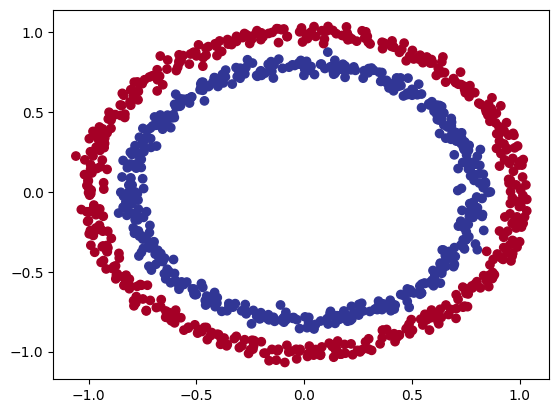

In [ ]:
# Visualization
import matplotlib.pyplot as plt
plt.scatter(x=x[:, 0],
            y=x[:,1],
            c=y,
            cmap=plt.cm.RdYlBu);


**NOTE** :- The data we're working with is often referred as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundalmentals *italicised text*

In [ ]:
x.shape,y.shape

((1000, 2), (1000,))

In [ ]:
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
# View the first example of features and labels
x_sample = x[0]
y_sample = y[0]

print(f"Values for one sample of X: {x_sample} && the same for Y: {y_sample} \n ")
print(f"Shape for one sample of X: {x_sample.shape} and the same for y: {y_sample.shape} \n")

Values for one sample of X: [0.75424625 0.23148074] && the same for Y: 1 
 
Shape for one sample of X: (2,) and the same for y: () 



1.2 Turn data into tensors and create train and test splits

In [ ]:
import torch

In [ ]:
type(x),x.dtype

(numpy.ndarray, dtype('float64'))

In [ ]:
# Turn data into tensors
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

x[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
type(x), x.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [ ]:
#Split data into training and test data
from sklearn.model_selection import train_test_split

x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,
                                                  random_state=42)

In [ ]:
len(x_train), len(x_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [ ]:
n_samples

1000

##  2. Building a model

Let's build a model to classify our blue and red dots

To do so, we want to:
  1. Setup device agonistic code so our code will run on an accelerator(GPU) if there is one present.
  2. Construct a model(by subclassing nn.Module).
  3. Define a loss function and optimizer  
  4. Create a training and test loop

In [ ]:
#Import Pytorch and nn
import torch
from torch import nn

# Make device agonistic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
x_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

In [ ]:
y_train[:5]

tensor([1., 0., 0., 0., 1.])

Now we've setup device agonistic code, let's create a model that:


1. Subclasses `nn.Module` (Almost all models in Pytorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data.
3. Define a `forward()` method that outlines the forward pass( or forward computation of the model)
4. Instatiate an instance of our model class and send it to the target device

In [ ]:
class CircleModelV0(nn.Module):
      def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features
        self.layer_2 = nn.Linear(in_features=5,out_features=1)
        # takes in 5 features from previous layer and outputs a single feature

        self.two_linear_layers = nn.Sequential(
               nn.Linear(in_features=2,out_features=5),
               nn.Linear(in_features=5,out_features=1)
              )

        #3. Define a forward() method that outlines the forward pass
      def forward(self,x):
          return self.layer_2(self.layer_1(x)) # x-> layer 1 -> layer 2 -> output
          return two_linear_layers(x)


# 4. Instatiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [ ]:
device

'cpu'

In [ ]:
next(model_0.parameters()).device

device(type='cpu')

In [ ]:
# Let's replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
     nn.Linear(in_features=2,out_features=5),
     nn.Linear(in_features=5,out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2976,  0.6313],
                      [ 0.4087, -0.3091],
                      [ 0.4082,  0.1265],
                      [ 0.3591, -0.4310],
                      [-0.7000, -0.2732]])),
             ('0.bias', tensor([-0.5424,  0.5802,  0.2037,  0.2929,  0.2236])),
             ('1.weight',
              tensor([[-0.0078,  0.3500, -0.3178,  0.0282, -0.3052]])),
             ('1.bias', tensor([0.1379]))])

In [ ]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(x_test.to(device))
print(f"Length of predictions: {len(untrained_preds)},Shape :{untrained_preds.shape}")
print(f"Length of test samples: {len(x_test)}, Shape:{x_test.shape}")
print(f"\n First 10 predictions: \n {torch.round(untrained_preds[:10])}")
print(f"\n First 10 labels: \n {y_test[:10]}")

Length of predictions: 200,Shape :torch.Size([200, 1])
Length of test samples: 200, Shape:torch.Size([200, 2])

 First 10 predictions: 
 tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])

 First 10 labels: 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


## 2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specific.

For example for regression you might want MAE or MSE (Mean absolute error or mean squared error)

For classification you might want binary cross entropy or categorical cross entropy

In context of deep learning the logits layer means the layer that feeds in to softmax. The output of the softmax are the probablities for the classification task and its input is logits layer

* For the binary loss function we are going to use `torch.nn.BECWithLogitsLoss()`, for more

In [ ]:
# Setup the loss function
# loss_fn = nn.BCE_Loss() # BCELoss = requires inputs to have gone through sigmoid activation function prior to BCELoss
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [ ]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right?

def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100;
    return acc


# Train model

To train our model, we're going to need to build a training loop:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step step step
(gradient descent)



# 3.1 Going from raw logits -> prediction probablities -> prediction labels


Our model output are going to be raw logits.


We can convert these **logits** into **prediction proabilities** by passing them to some kind of activation function(e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the argmax().

In [ ]:
#View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
   y_logits = model_0(x_test.to(device))[:5]
y_logits

tensor([[0.0763],
        [0.1453],
        [0.0813],
        [0.0742],
        [0.3760]])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs



tensor([[0.5191],
        [0.5363],
        [0.5203],
        [0.5185],
        [0.5929]])

For our prediction probability values, we need to perform a range-style rounding on them:

* `y_pred_probs`  >= 0.5, y=1 (class 1)
* `y_pred_probs` < 0.5, y=0 (class 0)


In [ ]:
torch.round(y_pred_probs)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])

In [ ]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)


# In full (logits-> pred prob -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

#Get rid of extra dimensions
y_preds.squeeze()


tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

# 3.2 Building a training and testing loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of the epochs
epochs = 1000

# Put data to target device
x_train,y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

# Build traing and evaluation loop
for epoch in range(epochs):
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(x_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))  # turn logits -> ped prob -> pred labels

  # 2. Calculate loss/accuracy
  # loss = loss_fn(torch.sigmoid(y_logits),
  #                  )
  loss = loss_fn(y_logits,  # nn.BCEWithLogitsLoss expects raw logits as input
                     y_train)
  acc = accuracy_fn(y_true=y_train,
                        y_pred=y_pred)
  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  model_0.eval()
  with torch.inference_mode():

       # 1.Forward pass
       test_logits = model_0(x_test).squeeze()
       test_pred = torch.round(torch.sigmoid(test_logits))

       # 2. Calculate the test loss/acc
       test_loss = loss_fn(test_logits,
                           y_test)
       test_acc = accuracy_fn(y_true=y_test,
                              y_pred=test_pred)

  if epoch%100 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:5f}, Acc: {acc:2f}% | Test Loss: {test_acc: 2f}%")


Epoch: 0 | Loss: 0.702335, Acc: 57.375000% | Test Loss:  57.000000%
Epoch: 100 | Loss: 0.693208, Acc: 49.750000% | Test Loss:  49.500000%
Epoch: 200 | Loss: 0.693016, Acc: 50.625000% | Test Loss:  47.500000%
Epoch: 300 | Loss: 0.692987, Acc: 50.750000% | Test Loss:  46.000000%
Epoch: 400 | Loss: 0.692981, Acc: 51.000000% | Test Loss:  45.500000%
Epoch: 500 | Loss: 0.692980, Acc: 51.000000% | Test Loss:  45.500000%
Epoch: 600 | Loss: 0.692980, Acc: 51.375000% | Test Loss:  46.000000%
Epoch: 700 | Loss: 0.692980, Acc: 51.125000% | Test Loss:  46.000000%
Epoch: 800 | Loss: 0.692980, Acc: 51.125000% | Test Loss:  46.000000%
Epoch: 900 | Loss: 0.692980, Acc: 51.125000% | Test Loss:  46.000000%


## 4. Make predictiona and evaluate the model

From the metrics it looks like our model isn't learning anything...

So to inspect it let's make some predictions and make them visuals!

In other words, "Visualize, visualize, visualize"

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("Helper function.py already exist,skipping downloads")
else:
  print("Download helper_function.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
     f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Helper function.py already exist,skipping downloads


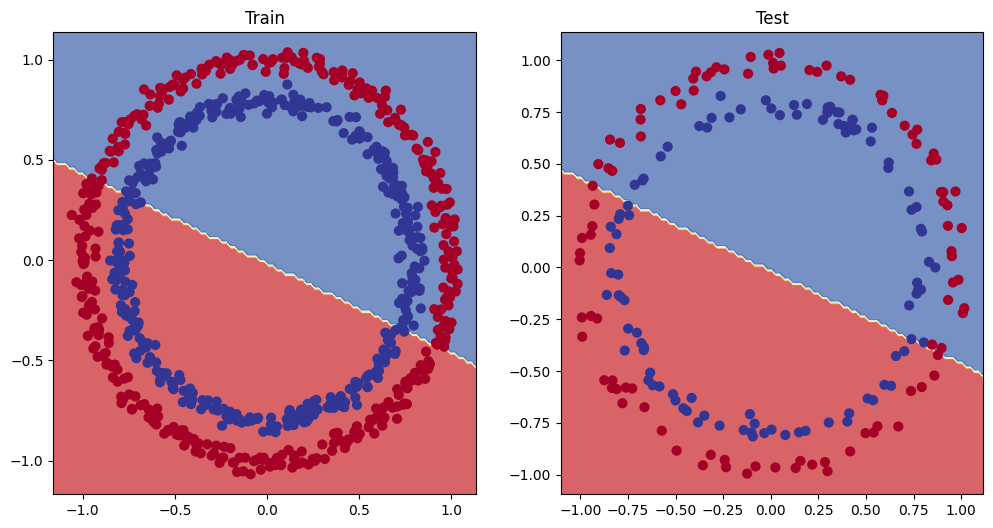

In [ ]:
# PLot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,x_test,y_test)


In [ ]:
loss_fn_without_logits = nn.BCELoss()
loss_fn_without_logits

BCELoss()

# Improving a model (from model perpective)

* Add more layers - give the model more chances to learn about patterns in the data.
* Add more hidden layers - go from 5 hidden layers to 10 hidden layers
* Fit for longer
* Changing the activation function
* Changing the learning rate
* Changing the optimization function


In [ ]:
x_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self,x):
    z = self.layer_1(x)
    z = self.layer_2(z)
    z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing  operations leverages speed ups where possible behined the scenes

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Create a loss functions
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)


In [ ]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

for epoch in range(epochs):
   # Training
    model_1.train()

   # 1. Forward pass
    y_logits = model_1(x_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    # logits -> pred prob -> pred labels

    # 2. Calculate the loss/acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss backwards
    loss.backward()

    #5. Optimizer step
    optimizer.step()

    ## Testing
    model_1.eval()
    with torch.inference_mode():

         # 1. Forward pass
         test_logits = model_1(x_test).squeeze()
         test_pred = torch.round(torch.sigmoid(test_logits))

         # 2. Calculates loss
         test_loss = loss_fn(test_logits, y_test)
         test_acc = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)

    if epoch%100 ==0:
      print(f"Epoch: {epoch} | Loss: {loss: 5f} , Acc: {acc:2f}% | Test loss:{test_loss:5f}, Test acc:{test_acc:2f}%")




Epoch: 0 | Loss:  0.693955 , Acc: 50.875000% | Test loss:0.692615, Test acc:51.000000%
Epoch: 100 | Loss:  0.693048 , Acc: 50.375000% | Test loss:0.693790, Test acc:48.000000%
Epoch: 200 | Loss:  0.692986 , Acc: 51.125000% | Test loss:0.694373, Test acc:46.000000%
Epoch: 300 | Loss:  0.692981 , Acc: 51.625000% | Test loss:0.694577, Test acc:45.000000%
Epoch: 400 | Loss:  0.692980 , Acc: 51.125000% | Test loss:0.694645, Test acc:46.000000%
Epoch: 500 | Loss:  0.692980 , Acc: 51.000000% | Test loss:0.694668, Test acc:46.000000%
Epoch: 600 | Loss:  0.692980 , Acc: 51.000000% | Test loss:0.694676, Test acc:46.000000%
Epoch: 700 | Loss:  0.692980 , Acc: 51.000000% | Test loss:0.694678, Test acc:46.000000%
Epoch: 800 | Loss:  0.692980 , Acc: 51.000000% | Test loss:0.694679, Test acc:46.000000%
Epoch: 900 | Loss:  0.692980 , Acc: 51.000000% | Test loss:0.694679, Test acc:46.000000%


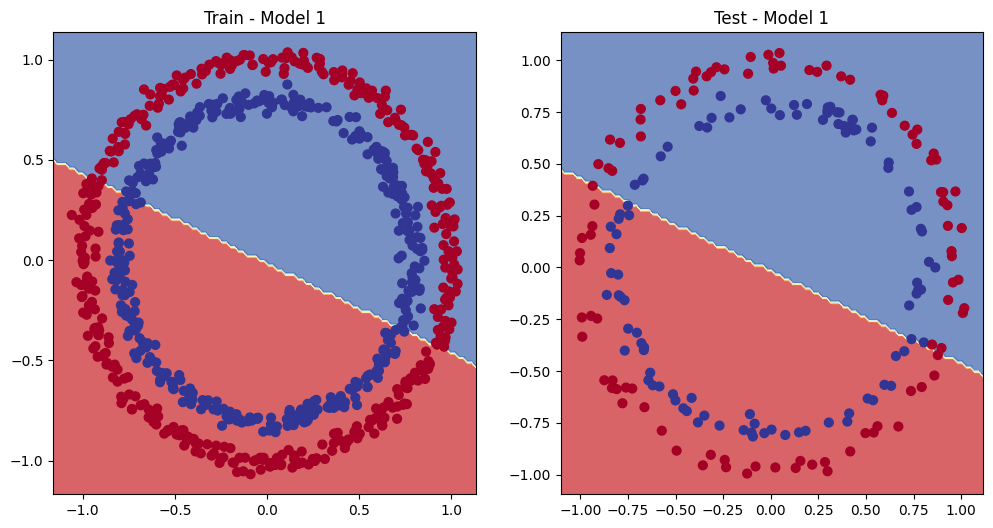

In [ ]:
import matplotlib.pyplot as plt

# Plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train - Model 1")
plot_decision_boundary(model_1,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test - Model 1")
plot_decision_boundary(model_1,x_test,y_test)

## 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot a larger problem is to test out on smaller problem

In [ ]:
# Create some data
weight = 0.7
bias =0.3
start = 0
end=1
step=0.01

# Create data
x_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression = weight*x_regression+ bias

# Check the data
print(len(x_regression))
x_regression[:5] , y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# Create train0test splits
train_split = int(0.8 * len(x_regression))
x_train_regression, y_train_regression = x_regression[:train_split], y_regression[:train_split]
x_test_regression, y_test_regression = x_regression[train_split:], y_regression[train_split:]

# Check the length of each
len(x_train_regression),len(x_test_regression), len(y_train_regression),len(y_test_regression)

(80, 20, 80, 20)

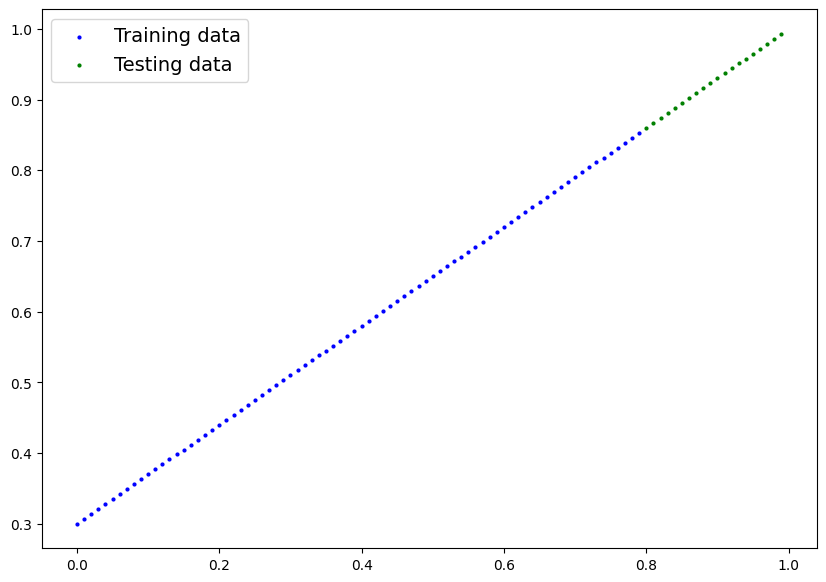

In [ ]:
plot_predictions(train_data=x_train_regression,
                 train_labels= y_train_regression,
                 test_data=x_test_regression,
                 test_labels=y_test_regression)

## 5.2 Adjusting model_1 to fit a straight line

In [ ]:
model_2 = nn.Sequential(
     nn.Linear(in_features=1, out_features=10),
     nn.Linear(in_features=10,out_features=10),
     nn.Linear(in_features=10,out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put data on device
x_train_regression = x_train_regression.to(device)
y_train_regression = y_train_regression.to(device)
x_test_regression = x_test_regression.to(device)
y_test_regression = y_test_regression.to(device)

for epoch in range(epochs):

    ### Training
    model_2.train()

    # 1. Forward pass
    y_pred = model_2(x_train_regression)

    # 2. Calculate loss (for regression typically MSELoss)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()


    ### Testing
    model_2.eval()
    with torch.inference_mode():

        # 1. Forward pass
        test_pred = model_2(x_test_regression)

        # 2. Calculate test loss
        test_loss = loss_fn(test_pred, y_test_regression)


    # Print every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | "
              f"Train Loss: {loss:.5f} | "
              f"Test Loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 0.75986 | Test Loss: 0.54143
Epoch: 100 | Train Loss: 0.09309 | Test Loss: 0.02901
Epoch: 200 | Train Loss: 0.07376 | Test Loss: 0.02850
Epoch: 300 | Train Loss: 0.06745 | Test Loss: 0.00615
Epoch: 400 | Train Loss: 0.06107 | Test Loss: 0.02004
Epoch: 500 | Train Loss: 0.05698 | Test Loss: 0.01061
Epoch: 600 | Train Loss: 0.04857 | Test Loss: 0.01326
Epoch: 700 | Train Loss: 0.06109 | Test Loss: 0.02127
Epoch: 800 | Train Loss: 0.05600 | Test Loss: 0.01425
Epoch: 900 | Train Loss: 0.05571 | Test Loss: 0.00603


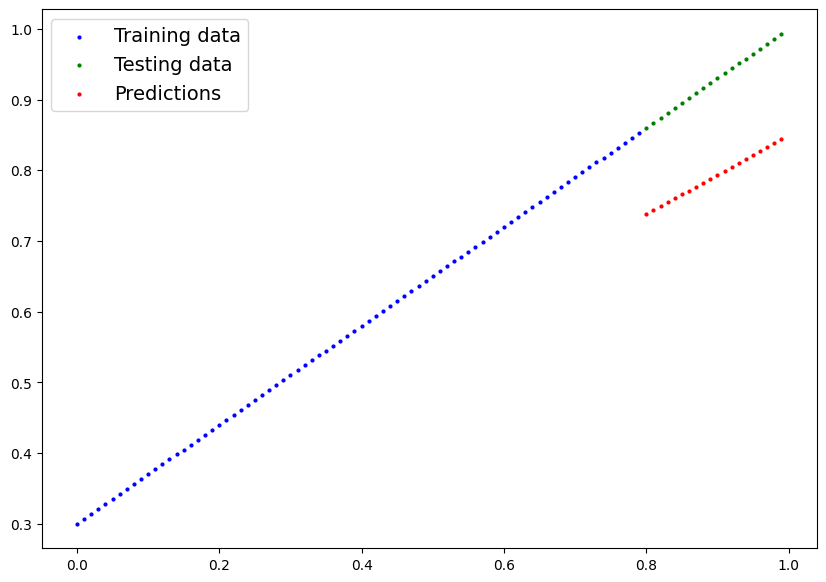

In [ ]:
#Turn on evaluation mode
model_2.eval()

# Make predictions inference
with torch.inference_mode():
  y_preds = model_2(x_test_regression)

# Plot data and predictions
plot_predictions(train_data=x_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=x_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())



# 6. The missing piece: non-linearity

"What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"

Or in machine learning terms, an infinite (but reality it is finite) of linear and non-l


6.1 Recreating non-linear data (red and blue circles)

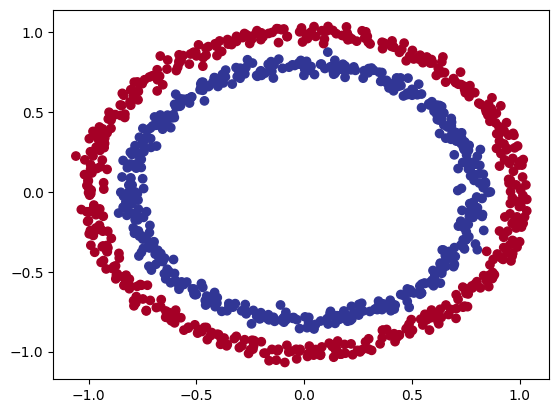

In [ ]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

x,y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

plt.scatter(x[:,0], x[:,1], c=y,
                        cmap=plt.cm.RdYlBu);

In [ ]:
# Convert data into tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
x = torch.from_numpy(x).type(torch.float)
y =  torch.from_numpy(y).type(torch.float)

# Split into test and train sets
x_train, y_train,x_test, y_test = train_test_split(x,y,
                                                  test_size=0.2,
                                                  random_state=42)

x_train[:5], y_train[:5]

## 6.2 Building a model with non-linearity

* Linear = straight linear
* Non-linear = non straight lines

In [ ]:
# Build a model with non-linear activation functions
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3